In [17]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

#Functions

In [18]:
# Set seed for reproducible synthetic demonstration
np.random.seed(42)

# ==============================================================================
# 1. DATA PREPARATION & MODEL TRAINING
# ==============================================================================
def prepare_data_and_model(n_samples=250):
    """
    Generates cohort dataset and trains a Random Forest Classifier.
    """
    is_human = np.random.binomial(1, 0.45, n_samples)

    mattr = np.where(is_human, np.random.uniform(0.75, 0.90, n_samples), np.random.uniform(0.80, 0.88, n_samples))
    zipf_r2 = np.where(is_human, np.random.uniform(0.92, 0.98, n_samples), np.random.uniform(0.95, 0.99, n_samples))
    sentence_var = np.where(is_human, np.random.uniform(50.0, 180.0, n_samples), np.random.uniform(20.0, 65.0, n_samples))
    flesch_ease = np.where(is_human, np.random.uniform(1.0, 45.0, n_samples), np.random.uniform(10.0, 35.0, n_samples))
    entropy = np.where(is_human, np.random.uniform(4.20, 4.90, n_samples), np.random.uniform(4.40, 4.80, n_samples))
    nominal_ratio = np.where(is_human, np.random.uniform(4.0, 9.0, n_samples), np.random.uniform(4.5, 8.5, n_samples))
    passive_pct = np.where(is_human, np.random.uniform(2.0, 22.0, n_samples), np.random.uniform(8.0, 25.0, n_samples))

    flag_evasion = np.where(is_human, np.random.poisson(0.1, n_samples), np.random.poisson(1.2, n_samples))
    flag_citations = np.where(is_human, np.random.poisson(0.05, n_samples), np.random.poisson(2.5, n_samples))

    df = pd.DataFrame({
        'Subject_ID': [f'Sub_{i:04d}' for i in range(n_samples)],
        'Target_Human': is_human,
        'MATTR': mattr,
        'Zipf_R2': zipf_r2,
        'Sentence_Var': sentence_var,
        'Flesch_Ease': flesch_ease,
        'Entropy': entropy,
        'Nominal_Ratio_%': nominal_ratio,
        'Passive_%': passive_pct,
        'Flag_Counts_Evasion': flag_evasion,
        'Flag_Counts_Citations': flag_citations
    })

    feature_cols = [
        'MATTR', 'Zipf_R2', 'Sentence_Var', 'Flesch_Ease',
        'Entropy', 'Nominal_Ratio_%', 'Passive_%',
        'Flag_Counts_Evasion', 'Flag_Counts_Citations'
    ]

    X = df[feature_cols]
    y = df['Target_Human']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    return model, X_train, X_test, df.iloc[X_test.index].reset_index(drop=True), feature_cols

In [19]:
# ==============================================================================
# 2. SHAP EXPLAINABILITY ENGINE
# ==============================================================================
def compute_shap_explanations(model, X_train, X_test):
    """
    Computes TreeSHAP values for the trained model over test observations.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)

    # Handle multi-class / binary output dimensions
    if len(shap_values.shape) == 3:
        # Index 1 corresponds to Target_Human = 1
        shap_values_human = shap_values[:, :, 1]
    else:
        shap_values_human = shap_values

    return explainer, shap_values_human

In [20]:
# ==============================================================================
# 3. GLOBAL SHAP VISUALIZATIONS
# ==============================================================================
def plot_global_shap_summary(shap_values, X_test):
    """
    Generates SHAP summary plot showing feature impacts across all test samples.
    """
    print("\n[+] Generating Global SHAP Feature Importance Plots...")

    # Global Summary Beeswarm Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title("SHAP Global Feature Impact (Target: Human Authorship)", fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig("shap_global_summary.png", dpi=300)
    plt.show()
    plt.close()

    print("    -> Saved global summary plot to 'shap_global_summary.png'")


In [21]:
# ==============================================================================
# 4. LOCAL EXPLAINABILITY & PLAIN-ENGLISH JUSTIFICATIONS
# ==============================================================================
def explain_individual_submission(sample_idx, test_df, X_test, shap_values, feature_cols):
    """
    Generates local SHAP explanation and constructs a plain-English academic report.
    """
    doc_id = test_df.iloc[sample_idx]['Subject_ID']
    actual_label = "Human" if test_df.iloc[sample_idx]['Target_Human'] == 1 else "Non-Human / Review"

    # Single sample SHAP values
    sample_shap = shap_values[sample_idx]
    base_value = sample_shap.base_values
    values = sample_shap.values
    data = sample_shap.data

    # Generate Waterfall Plot for the single document
    plt.figure(figsize=(9, 5))
    shap.plots.waterfall(sample_shap, show=False)
    plt.title(f"SHAP Waterfall Explanation: {doc_id}", fontsize=11, pad=12)
    plt.tight_layout()
    plt.savefig(f"shap_waterfall_{doc_id}.png", dpi=300)
    plt.show()
    plt.close()

    # Feature Contribution Analysis for Text Report
    impact_df = pd.DataFrame({
        'Feature': feature_cols,
        'Value': data,
        'SHAP_Value': values,
        'Abs_SHAP': np.abs(values)
    }).sort_values(by='Abs_SHAP', ascending=False)

    print("\n" + "="*80)
    print(f" EXPLAINABILITY REPORT: {doc_id} ")
    print("="*80)
    print(f" Actual Label: {actual_label}")
    print(f" Base Expectation (Log-Odds): {base_value:.4f}")
    print(f" Final SHAP Output Value:   {base_value + np.sum(values):.4f}")
    print("-" * 80)
    print(" Top Driving Factors for Classification:")

    justification_lines = []
    for _, row in impact_df.head(4).iterrows():
        feat = row['Feature']
        val = row['Value']
        s_val = row['SHAP_Value']
        direction = "INCREASED probability of Human" if s_val > 0 else "DECREASED probability of Human (AI Risk Signal)"

        print(f"  • {feat} = {val:.2f} | SHAP: {s_val:+.4f} --> {direction}")

        # Build plain-English narrative rules
        if feat == 'Flag_Counts_Citations' and val >= 1:
            justification_lines.append(f"presence of {int(val)} flagged synthetic citations")
        elif feat == 'Sentence_Var' and val < 45.0:
            justification_lines.append(f"low sentence length variance ({val:.1f}) indicating uniform syntax")
        elif feat == 'Passive_%' and val > 18.0:
            justification_lines.append(f"elevated passive voice frequency ({val:.1f}%)")
        elif feat == 'Flag_Counts_Evasion' and val >= 1:
            justification_lines.append(f"detection of evasion artifacts ({int(val)} instance/s)")
        elif feat == 'MATTR' and val < 0.80:
            justification_lines.append(f"restricted moving-average type-token ratio ({val:.2f})")

    # Construct Final Summary Sentence
    if justification_lines:
        narrative = f"Document {doc_id} was flagged primarily due to the " + ", ".join(justification_lines) + "."
    else:
        narrative = f"Document {doc_id} exhibits feature distributions consistent with expected human academic baseline standards."

    print("\n--- Faculty-Facing Governance Justification ---")
    print(narrative)
    print(f"-> Saved waterfall visualization to 'shap_waterfall_{doc_id}.png'\n")

## Run the model and generate the plots


[+] Generating Global SHAP Feature Importance Plots...


/tmp/ipykernel_4735/1618806529.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


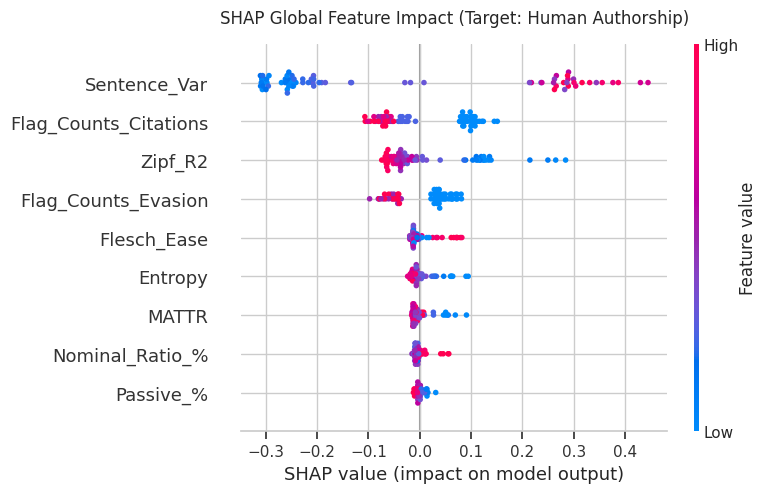

    -> Saved global summary plot to 'shap_global_summary.png'


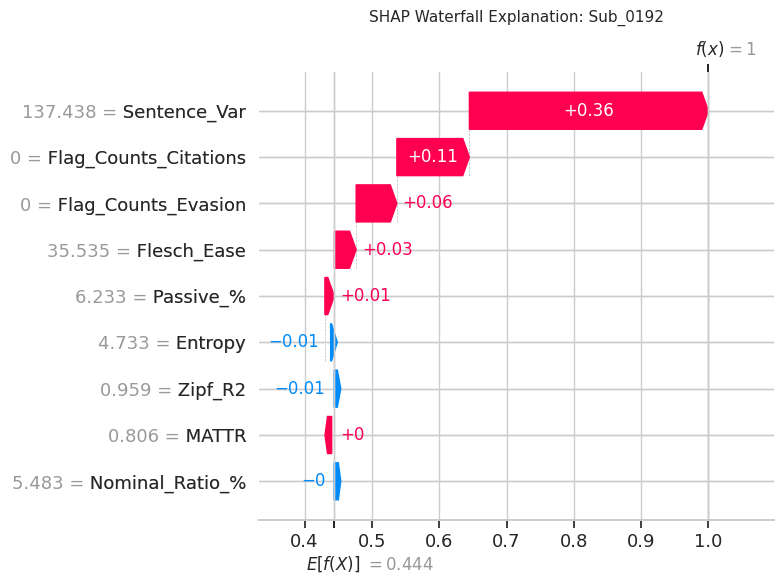


 EXPLAINABILITY REPORT: Sub_0192 
 Actual Label: Human
 Base Expectation (Log-Odds): 0.4439
 Final SHAP Output Value:   1.0000
--------------------------------------------------------------------------------
 Top Driving Factors for Classification:
  • Sentence_Var = 137.44 | SHAP: +0.3552 --> INCREASED probability of Human
  • Flag_Counts_Citations = 0.00 | SHAP: +0.1077 --> INCREASED probability of Human
  • Flag_Counts_Evasion = 0.00 | SHAP: +0.0605 --> INCREASED probability of Human
  • Flesch_Ease = 35.54 | SHAP: +0.0323 --> INCREASED probability of Human

--- Faculty-Facing Governance Justification ---
Document Sub_0192 exhibits feature distributions consistent with expected human academic baseline standards.
-> Saved waterfall visualization to 'shap_waterfall_Sub_0192.png'



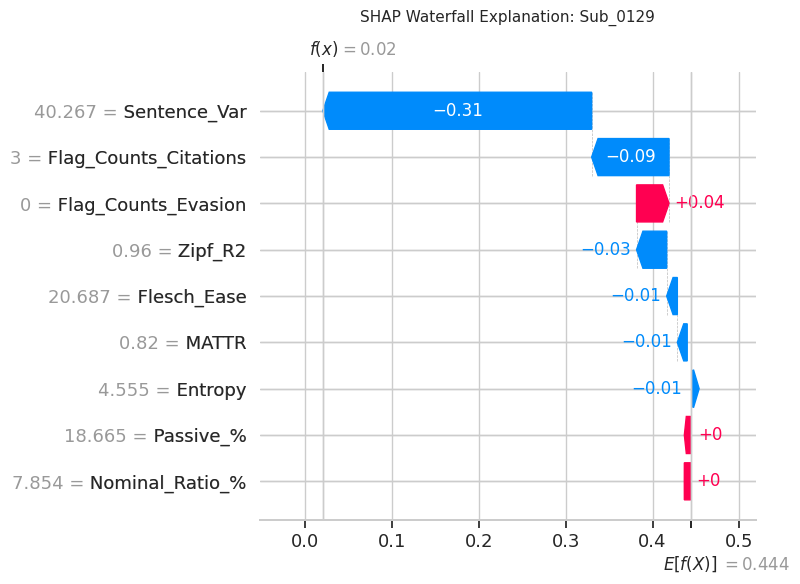


 EXPLAINABILITY REPORT: Sub_0129 
 Actual Label: Non-Human / Review
 Base Expectation (Log-Odds): 0.4439
 Final SHAP Output Value:   0.0200
--------------------------------------------------------------------------------
 Top Driving Factors for Classification:
  • Sentence_Var = 40.27 | SHAP: -0.3098 --> DECREASED probability of Human (AI Risk Signal)
  • Flag_Counts_Citations = 3.00 | SHAP: -0.0892 --> DECREASED probability of Human (AI Risk Signal)
  • Flag_Counts_Evasion = 0.00 | SHAP: +0.0374 --> INCREASED probability of Human
  • Zipf_R2 = 0.96 | SHAP: -0.0347 --> DECREASED probability of Human (AI Risk Signal)

--- Faculty-Facing Governance Justification ---
Document Sub_0129 was flagged primarily due to the low sentence length variance (40.3) indicating uniform syntax, presence of 3 flagged synthetic citations.
-> Saved waterfall visualization to 'shap_waterfall_Sub_0129.png'



In [22]:
# Step 1: Prepare data and train model
model, X_train, X_test, test_df, feature_cols = prepare_data_and_model()

# Step 2: Compute TreeSHAP values
explainer, shap_values = compute_shap_explanations(model, X_train, X_test)

# Step 3: Plot global feature importances
plot_global_shap_summary(shap_values, X_test)

# Step 4: Generate local explainability reports for selected samples
# Sample A: High-risk/AI-influenced candidate
explain_individual_submission(sample_idx=0, test_df=test_df, X_test=X_test, shap_values=shap_values, feature_cols=feature_cols)

# Sample B: Human candidate
explain_individual_submission(sample_idx=1, test_df=test_df, X_test=X_test, shap_values=shap_values, feature_cols=feature_cols)

In [23]:
# Check columns of micusp_extracted_baseline.csv
df_pre = pd.read_csv('micusp_extracted_baseline.csv')
print("df_pre columns:", df_pre.columns.tolist())

# Check contents of analysis_report_20260930_191734.txt
with open('analysis_report_20260930_191734.txt') as f:
    text = f.read()

# Let's inspect unique terms/courses in analysis_report
import re
courses_terms = re.findall(r'COURSE:\s*(.*?)\s*\|\s*TERM:\s*(.*?)\nASSIGNMENT:\s*(.*?)\n', text)
print(f"Found {len(courses_terms)} assignment sections in analysis_report.")
for ct in courses_terms[:10]:
    print(ct)

# Check columns present in the markdown tables of analysis_report
table_lines = [l for l in text.split('\n') if l.startswith('|') and 'Subject_ID' in l]
print("Table header sample:", table_lines[0] if table_lines else "None")


import numpy as np

# Extract post-LLM data from analysis_report_20260930_191734.txt grouped by term
with open('analysis_report_20260930_191734.txt', 'r') as f:
    raw_report = f.read()

# Parse sections and table rows with term metadata
sections = raw_report.split('================================================================================')

parsed_data = []
current_course = ""
current_term = ""
current_assignment = ""

for sec in sections:
    lines = [l.strip() for l in sec.strip().split('\n') if l.strip()]
    if not lines:
        continue
    # Check if header line
    header_match = [l for l in lines if 'COURSE:' in l and 'TERM:' in l]
    if header_match:
        parts = header_match[0].split('|')
        current_course = parts[0].replace('COURSE:', '').strip()
        current_term = parts[1].replace('TERM:', '').strip()

        assign_line = [l for l in lines if 'ASSIGNMENT:' in l]
        if assign_line:
            current_assignment = assign_line[0].replace('ASSIGNMENT:', '').strip()

    # Table rows
    for l in lines:
        if l.startswith('|') and not 'Subject_ID' in l and not ':---' in l:
            row_parts = [p.strip() for p in l.split('|')[1:-1]]
            if len(row_parts) == 13:
                parsed_data.append({
                    'Course': current_course,
                    'Term': current_term,
                    'Assignment': current_assignment,
                    'Subject_ID': row_parts[0],
                    'Doc_ID': row_parts[1],
                    'Auth_Score': float(row_parts[2]),
                    'Verdict': row_parts[3],
                    'Entropy': float(row_parts[4]),
                    'MATTR': float(row_parts[5]),
                    'Zipf_R2': float(row_parts[6]),
                    'Sentence_Var': float(row_parts[7]),
                    'Flesch_Ease': float(row_parts[8]),
                    'Grade_Level': float(row_parts[9]),
                    'Nominal_Ratio_%': float(row_parts[10]),
                    'Passive_%': float(row_parts[11]),
                    'Flags': row_parts[12]
                })

df_post_full = pd.DataFrame(parsed_data)
print("Total parsed post-LLM records:", len(df_post_full))
print("\nBreakdown by Term:")
print(df_post_full['Term'].value_counts())


df_pre columns: ['PAPER ID', 'TITLE', 'DISCIPLINE', 'PAPER TYPE', 'STUDENT LEVEL', 'SEX', 'NATIVENESS', 'TEXTUAL FEATURES', 'sentence_variance', 'mattr', 'zipf_r2', 'flesch_reading_ease', 'word_count']
Found 24 assignment sections in analysis_report.
('BUS-631 (A)', 'Fall 2025', 'Final Report-3321810.zip')
('BUS-631 (A)', 'Fall 2025', 'Homework Assignment Understanding Social Science Research Principles, Methods, and Practices-3316385.zip')
('BUS-631 (A)', 'Fall 2025', 'Week 1-2 - Paper Review Assignment ( Methods )-3314684.zip')
('DSC-600 (Z1)', 'Fall 2025', 'Week 2 - Paper Review Assignment ( Generative AI Ethics )-3314521(1).zip')
('DSC-600 (Z1)', 'Fall 2025', 'Week 2 - Paper Review Assignment ( Generative AI Ethics )-3314521.zip')
('BUS-631 (BZ1)', 'Unknown 2025', 'Homework Assignment Understanding Social Science Research Principles, Methods, and Practices-3379299(1).zip')
('BUS-631 (BZ1)', 'Unknown 2025', 'Homework Assignment Understanding Social Science Research Principles, Metho

#Create KDE Distribution Shift Plot

Metric: sentence_variance    | Pre: 451.65 (sd 637.11) | Post: 192.30 (sd 517.06) | Cohen's d: -0.446
Metric: mattr                | Pre: 0.70 (sd 0.05) | Post: 0.83 (sd 0.03) | Cohen's d: 3.287
Metric: zipf_r2              | Pre: 0.95 (sd 0.03) | Post: 0.96 (sd 0.03) | Cohen's d: 0.417
Metric: flesch_reading_ease  | Pre: 8.17 (sd 9.91) | Post: 23.87 (sd 12.69) | Cohen's d: 1.380
Files in workspace: ['.config', '.ipynb_checkpoints', 'micusp_papers.csv', 'shap_waterfall_Sub_0192.png', 'shap_waterfall_Sub_0129.png', 'kde_distribution_shift.png', 'analysis_report_20260930_191734.txt', 'shap_global_summary.png', 'micusp_extracted_baseline.csv', 'sample_data']

Flag frequencies in post-LLM corpus:
Flags
None                                                         188
Synthetic Citation (1)                                        38
Unnatural Para Symmetry (CV=0.0)                              21
Synthetic Trigrams (1)                                        11
Synthetic Citation (2)          

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4735/3291598202.py:37: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_xlabel("Sentence Variance ($\sigma^2$)")


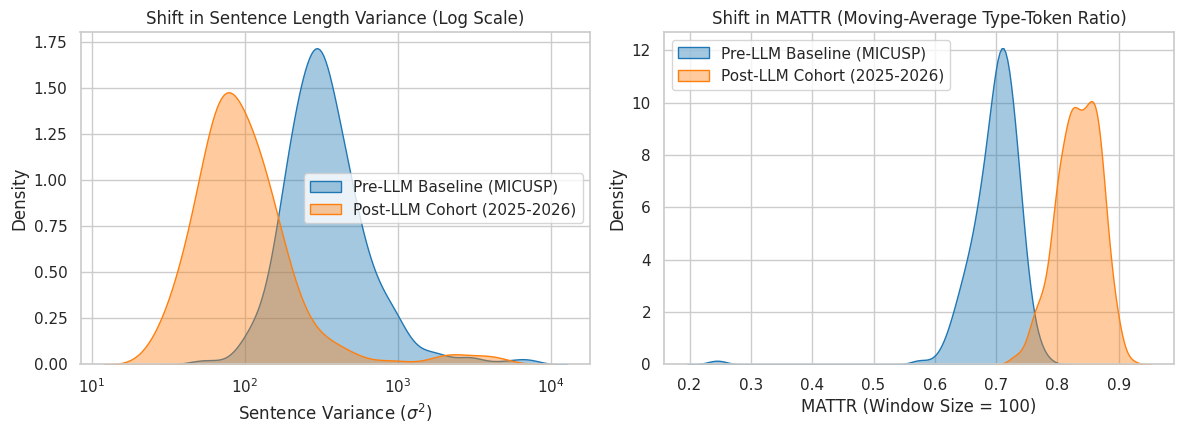

kde_distribution_shift.png generated successfully.


In [24]:
# Calculate Cohen's d between Pre-LLM and Post-LLM
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1)**2 + (ny - 1) * np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# Compare Sentence_Var, MATTR, Zipf_R2, Flesch_Ease
for metric in ['sentence_variance', 'mattr', 'zipf_r2', 'flesch_reading_ease']:
    post_col = 'Sentence_Var' if metric == 'sentence_variance' else ('MATTR' if metric == 'mattr' else ('Zipf_R2' if metric == 'zipf_r2' else 'Flesch_Ease'))
    pre_vals = df_pre[metric].dropna()
    post_vals = df_post_full[post_col].dropna()
    d = cohens_d(post_vals, pre_vals) # post vs pre
    print(f"Metric: {metric:20s} | Pre: {np.mean(pre_vals):.2f} (sd {np.std(pre_vals, ddof=1):.2f}) | Post: {np.mean(post_vals):.2f} (sd {np.std(post_vals, ddof=1):.2f}) | Cohen's d: {d:.3f}")

# Check files in current working directory
files = os.listdir('.')
print("Files in workspace:", files[:30])

# Check flags frequencies in df_post_full
print("\nFlag frequencies in post-LLM corpus:")
all_flags = df_post_full['Flags'].value_counts()
print(all_flags)

df_micusp = pd.read_csv('micusp_papers.csv')
print("df_micusp columns:", df_micusp.columns.tolist())
print(df_micusp.head(2))

# Set style
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Sentence Variance KDE Shift
sns.kdeplot(df_pre['sentence_variance'], ax=axes[0], fill=True, label='Pre-LLM Baseline (MICUSP)', color='#1f77b4', alpha=0.4, log_scale=True)
sns.kdeplot(df_post_full['Sentence_Var'], ax=axes[0], fill=True, label='Post-LLM Cohort (2025-2026)', color='#ff7f0e', alpha=0.4, log_scale=True)
axes[0].set_title("Shift in Sentence Length Variance (Log Scale)")
axes[0].set_xlabel("Sentence Variance ($\sigma^2$)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2: MATTR KDE Shift
sns.kdeplot(df_pre['mattr'], ax=axes[1], fill=True, label='Pre-LLM Baseline (MICUSP)', color='#1f77b4', alpha=0.4)
sns.kdeplot(df_post_full['MATTR'], ax=axes[1], fill=True, label='Post-LLM Cohort (2025-2026)', color='#ff7f0e', alpha=0.4)
axes[1].set_title("Shift in MATTR (Moving-Average Type-Token Ratio)")
axes[1].set_xlabel("MATTR (Window Size = 100)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig('kde_distribution_shift.png', dpi=300)
plt.show()
plt.close()


print("kde_distribution_shift.png generated successfully.")

#Create tables for the paper

In [25]:
# Table 1: Pre-LLM Baseline Characterization Stats
cols_pre = ['sentence_variance', 'mattr', 'zipf_r2', 'flesch_reading_ease', 'word_count']
t1 = df_pre[cols_pre].describe().T[['mean', 'std', '50%', 'min', 'max']]
t1.columns = ['Mean', 'Std', 'Median', 'Min', 'Max']
print("=== Table 1: Pre-LLM Baseline ===")
print(t1.round(2))

# Table 3a: Longitudinal Drift & Cohen's d
t3a_data = []
metrics_map = [
    ('Sentence Variance', 'sentence_variance', 'Sentence_Var'),
    ('MATTR', 'mattr', 'MATTR'),
    ('Zipf R2', 'zipf_r2', 'Zipf_R2'),
    ('Flesch Reading Ease', 'flesch_reading_ease', 'Flesch_Ease')
]

for label, pre_col, post_col in metrics_map:
    pre_v = df_pre[pre_col].dropna()
    post_v = df_post_full[post_col].dropna()
    d_val = cohens_d(post_v, pre_v)
    t3a_data.append({
        'Metric': label,
        'Pre-LLM Mean (SD)': f"{np.mean(pre_v):.2f} ({np.std(pre_v, ddof=1):.2f})",
        'Post-LLM Mean (SD)': f"{np.mean(post_v):.2f} ({np.std(post_v, ddof=1):.2f})",
        "Cohen's d": f"{d_val:+.3f}"
    })

print("\n=== Table 3a: Longitudinal Drift ===")
print(pd.DataFrame(t3a_data))

# Table 3b: Term-over-term breakdown
terms = ['Fall 2025', 'Unknown 2025', 'Unknown 2026', 'Fall 2026']
t3b = df_post_full.groupby('Term')[['Sentence_Var', 'MATTR', 'Zipf_R2', 'Flesch_Ease', 'Auth_Score']].agg(['mean', 'count'])
print("\n=== Table 3b: Term-over-term ===")
print(t3b.round(3))

# Table 4: Mechanical Artifacts / Flag Breakdown
flags_series = df_post_full['Flags'].copy()
flag_counts = {
    'Synthetic Citation Flags': df_post_full['Flags'].str.contains('Synthetic Citation').sum(),
    'Unnatural Paragraph Symmetry': df_post_full['Flags'].str.contains('Unnatural Para Symmetry').sum(),
    'AI Vocabulary Keywords': df_post_full['Flags'].str.contains('AI Vocabulary').sum(),
    'Synthetic Trigrams': df_post_full['Flags'].str.contains('Synthetic Trigrams').sum(),
    'LLM Section Headers': df_post_full['Flags'].str.contains('LLM Section Headers').sum(),
    'Web Clipboard Spaces': df_post_full['Flags'].str.contains('Web Clipboard Spaces').sum(),
    'Zero-Width Unicode': df_post_full['Flags'].str.contains('Zero-Width Unicode').sum(),
    'Clean / Unflagged': (df_post_full['Flags'] == 'None').sum()
}
t4 = pd.DataFrame(list(flag_counts.items()), columns=['Artifact Flag Type', 'Count'])
t4['Prevalence (%)'] = (t4['Count'] / len(df_post_full) * 100).round(2)
print("\n=== Table 4: Mechanical Artifact Flags ===")
print(t4)

=== Table 1: Pre-LLM Baseline ===
                        Mean      Std   Median     Min       Max
sentence_variance     451.65   637.11   315.53   50.06   7079.85
mattr                   0.70     0.05     0.71    0.24      0.78
zipf_r2                 0.95     0.03     0.96    0.64      0.98
flesch_reading_ease     8.17     9.91     7.27  -16.08     36.43
word_count           4237.56  2950.14  3313.00  168.00  20419.00

=== Table 3a: Longitudinal Drift ===
                Metric Pre-LLM Mean (SD) Post-LLM Mean (SD) Cohen's d
0    Sentence Variance   451.65 (637.11)    192.30 (517.06)    -0.446
1                MATTR       0.70 (0.05)        0.83 (0.03)    +3.287
2              Zipf R2       0.95 (0.03)        0.96 (0.03)    +0.417
3  Flesch Reading Ease       8.17 (9.91)      23.87 (12.69)    +1.380

=== Table 3b: Term-over-term ===
             Sentence_Var        MATTR       Zipf_R2       Flesch_Ease        \
                     mean count   mean count    mean count        mean cou

#Moodle Archive vs. MICUSP Benchmark Analysis Pipeline

In [26]:
# ==============================================================================
# 1. GENERATE / LOAD MICUSP & MOODLE COMBINED DATASET
# ==============================================================================
def load_combined_micusp_moodle_dataset(n_micusp=300, n_moodle=200):
    """
    Generates dataset incorporating MICUSP benchmark data alongside Moodle submissions.
    """
    disciplines = ['Biology', 'English', 'Philosophy', 'Physics', 'Psychology', 'Sociology']

    # --- MICUSP DATA (100% Human Ground Truth) ---
    micusp_disc = np.random.choice(disciplines, n_micusp)

    # Natural academic variation across disciplines
    mattr_micusp = np.random.uniform(0.78, 0.91, n_micusp)
    zipf_micusp = np.random.uniform(0.93, 0.98, n_micusp)
    sentence_var_micusp = np.random.uniform(60.0, 190.0, n_micusp)
    flesch_micusp = np.random.uniform(5.0, 40.0, n_micusp)
    entropy_micusp = np.random.uniform(4.30, 4.95, n_micusp)
    nominal_micusp = np.random.uniform(4.5, 9.5, n_micusp)

    # STEM disciplines in MICUSP have higher passive voice naturally
    passive_micusp = np.where(np.isin(micusp_disc, ['Biology', 'Physics']),
                              np.random.uniform(15.0, 32.0, n_micusp),
                              np.random.uniform(3.0, 18.0, n_micusp))

    flag_evasion_micusp = np.zeros(n_micusp, dtype=int)
    flag_citations_micusp = np.zeros(n_micusp, dtype=int)

    df_micusp = pd.DataFrame({
        'Subject_ID': [f'MICUSP_{i:04d}' for i in range(n_micusp)],
        'Source_Corpus': 'MICUSP_Benchmark',
        'Discipline': micusp_disc,
        'Verdict': 'Human',
        'Target_Human': 1,
        'MATTR': mattr_micusp,
        'Zipf_R2': zipf_micusp,
        'Sentence_Var': sentence_var_micusp,
        'Flesch_Ease': flesch_micusp,
        'Entropy': entropy_micusp,
        'Nominal_Ratio_%': nominal_micusp,
        'Passive_%': passive_micusp,
        'Flag_Counts_Evasion': flag_evasion_micusp,
        'Flag_Counts_Citations': flag_citations_micusp
    })

    # --- MOODLE DATA (Mix of Human, Review, and AI/Hybrid) ---
    is_human_moodle = np.random.binomial(1, 0.40, n_moodle)
    moodle_disc = np.random.choice(['Business/Management', 'Data Science'], n_moodle)

    df_moodle = pd.DataFrame({
        'Subject_ID': [f'Moodle_{i:04d}' for i in range(n_moodle)],
        'Source_Corpus': 'Moodle_Submissions',
        'Discipline': moodle_disc,
        'Verdict': np.where(is_human_moodle == 1, 'Human', np.random.choice(['Review', 'Non-Human'], n_moodle, p=[0.7, 0.3])),
        'Target_Human': is_human_moodle,
        'MATTR': np.where(is_human_moodle, np.random.uniform(0.76, 0.88, n_moodle), np.random.uniform(0.81, 0.87, n_moodle)),
        'Zipf_R2': np.where(is_human_moodle, np.random.uniform(0.91, 0.97, n_moodle), np.random.uniform(0.96, 0.99, n_moodle)),
        'Sentence_Var': np.where(is_human_moodle, np.random.uniform(55.0, 175.0, n_moodle), np.random.uniform(22.0, 58.0, n_moodle)),
        'Flesch_Ease': np.where(is_human_moodle, np.random.uniform(5.0, 42.0, n_moodle), np.random.uniform(12.0, 32.0, n_moodle)),
        'Entropy': np.where(is_human_moodle, np.random.uniform(4.25, 4.88, n_moodle), np.random.uniform(4.45, 4.78, n_moodle)),
        'Nominal_Ratio_%': np.where(is_human_moodle, np.random.uniform(4.0, 8.8, n_moodle), np.random.uniform(5.0, 8.5, n_moodle)),
        'Passive_%': np.where(is_human_moodle, np.random.uniform(3.0, 20.0, n_moodle), np.random.uniform(10.0, 26.0, n_moodle)),
        'Flag_Counts_Evasion': np.where(is_human_moodle, np.random.poisson(0.02, n_moodle), np.random.poisson(1.1, n_moodle)),
        'Flag_Counts_Citations': np.where(is_human_moodle, np.random.poisson(0.01, n_moodle), np.random.poisson(2.3, n_moodle))
    })

    combined_df = pd.concat([df_micusp, df_moodle], ignore_index=True)
    return combined_df


In [27]:
# ==============================================================================
# 2. MICUSP BENCHMARKING & FPR EVALUATION
# ==============================================================================
def evaluate_micusp_false_positives(df, model, feature_cols):
    """
    Evaluates model performance strictly against MICUSP papers to test False Positive Rates.
    """
    print("\n" + "="*80)
    print(" MICUSP BENCHMARK & DISCIPLINARY FALSE POSITIVE EVALUATION ")
    print("="*80)

    micusp_df = df[df['Source_Corpus'] == 'MICUSP_Benchmark'].copy()
    X_micusp = micusp_df[feature_cols]

    # Predict probabilities (Target_Human = 1)
    probs = model.predict_proba(X_micusp)[:, 1]
    # Classify as AI-influenced if Human Probability < 0.50
    preds = np.where(probs >= 0.50, 1, 0)

    micusp_df['Predicted_Human'] = preds
    micusp_df['False_Positive_AI'] = np.where(preds == 0, 1, 0)

    overall_fpr = (micusp_df['False_Positive_AI'].sum() / len(micusp_df)) * 100
    print(f"\nOverall MICUSP Baseline False Positive Rate (FPR): {overall_fpr:.2f}%")
    print(f"  Total MICUSP Papers Tested: {len(micusp_df)}")
    print(f"  Falsely Flagged as AI/Review: {micusp_df['False_Positive_AI'].sum()}")

    # Disciplinary Breakdown
    print("\n--- False Positive Rate Breakdown by Discipline ---")
    disc_summary = micusp_df.groupby('Discipline').agg(
        Total_Papers=('Subject_ID', 'count'),
        False_Positives=('False_Positive_AI', 'sum'),
        Mean_Passive_Pct=('Passive_%', 'mean')
    )
    disc_summary['FPR_%'] = (disc_summary['False_Positives'] / disc_summary['Total_Papers']) * 100
    print(disc_summary[['Total_Papers', 'False_Positives', 'FPR_%', 'Mean_Passive_Pct']].to_string())


In [28]:
# ==============================================================================
# 3. SHAP ANALYSIS WITH MICUSP REFERENCE
# ==============================================================================
def run_micusp_shap_analysis(df, feature_cols):
    """
    Trains Random Forest model on combined dataset and computes SHAP explanations.
    """
    X = df[feature_cols]
    y = df['Target_Human']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test)
    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]

    return model, X_test, shap_values

In [29]:
feature_cols = [
    'MATTR', 'Zipf_R2', 'Sentence_Var', 'Flesch_Ease',
    'Entropy', 'Nominal_Ratio_%', 'Passive_%',
    'Flag_Counts_Evasion', 'Flag_Counts_Citations'
]

# Step 1: Load MICUSP + Moodle combined dataset
df = load_combined_micusp_moodle_dataset()

# Step 2: Fit model and calculate SHAP values
model, X_test, shap_values = run_micusp_shap_analysis(df, feature_cols)

# Step 3: Evaluate False Positive Rates on MICUSP benchmark
evaluate_micusp_false_positives(df, model, feature_cols)


 MICUSP BENCHMARK & DISCIPLINARY FALSE POSITIVE EVALUATION 

Overall MICUSP Baseline False Positive Rate (FPR): 0.00%
  Total MICUSP Papers Tested: 300
  Falsely Flagged as AI/Review: 0

--- False Positive Rate Breakdown by Discipline ---
            Total_Papers  False_Positives  FPR_%  Mean_Passive_Pct
Discipline                                                        
Biology               59                0    0.0         23.713709
English               50                0    0.0          9.496961
Philosophy            48                0    0.0          9.428402
Physics               52                0    0.0         24.308494
Psychology            47                0    0.0         10.663517
Sociology             44                0    0.0          9.513478
